# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import importlib, json, os, pathlib, subprocess, sys, tempfile
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
VERSION = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
EXPECTED_SOURCE_HASH = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
REQUIRED_FILES = ["assets/audio/notebooks/01_el_problema_de_modelar_secuencias_intro.mp3","assets/audio/notebooks/02_tokens_vocabulario_y_batches_intro.mp3","assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3","assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3","assets/audio/notebooks/05_tensores_del_transformer_intro.mp3","assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3","assets/audio/notebooks/07_queries_keys_y_values_intro.mp3","assets/audio/notebooks/08_self_attention_matricial_intro.mp3","assets/audio/notebooks/09_atencion_causal_intro.mp3","assets/audio/notebooks/10_multi_head_attention_intro.mp3","assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3","assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3","assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3","assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3","assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3","assets/audio/notebooks/16_proyecto_final_intro.mp3","assets/audio/presentacion_curso.mp3","assets/figures/00_presentacion_del_curso.png","assets/figures/01_el_problema_de_modelar_secuencias.png","assets/figures/02_tokens_vocabulario_y_batches.png","assets/figures/03_embeddings_y_geometria_de_tokens.png","assets/figures/04_posicion_y_orden_en_secuencias.png","assets/figures/05_tensores_del_transformer.png","assets/figures/06_atencion_como_mezcla_ponderada.png","assets/figures/07_queries_keys_y_values.png","assets/figures/08_self_attention_matricial.png","assets/figures/09_atencion_causal.png","assets/figures/10_multi_head_attention.png","assets/figures/11_residuales_layernorm_y_mlp.png","assets/figures/12_bloque_transformer_decoder.png","assets/figures/13_mini_gpt_desde_cero.png","assets/figures/14_entrenamiento_autoregresivo.png","assets/figures/15_generacion_interpretacion_y_limites.png","assets/figures/16_proyecto_final.png","assets/readings/unit-10-nota-tecnica.pdf","assets/readings/unit-11-nota-tecnica.pdf","assets/readings/unit-12-nota-tecnica.pdf","assets/readings/unit-13-nota-tecnica.pdf","assets/readings/unit-14-nota-tecnica.pdf","assets/readings/unit-15-nota-tecnica.pdf","assets/readings/unit-16-nota-tecnica.pdf","assets/readings/unit-2-nota-tecnica.pdf","assets/readings/unit-3-nota-tecnica.pdf","assets/readings/unit-4-nota-tecnica.pdf","assets/readings/unit-5-nota-tecnica.pdf","assets/readings/unit-6-nota-tecnica.pdf","assets/readings/unit-7-nota-tecnica.pdf","assets/readings/unit-8-nota-tecnica.pdf","assets/readings/unit-9-nota-tecnica.pdf","notebooks/unit-1.ipynb","notebooks/unit-10.ipynb","notebooks/unit-11.ipynb","notebooks/unit-12.ipynb","notebooks/unit-13.ipynb","notebooks/unit-14.ipynb","notebooks/unit-15.ipynb","notebooks/unit-16.ipynb","notebooks/unit-17.ipynb","notebooks/unit-2.ipynb","notebooks/unit-3.ipynb","notebooks/unit-4.ipynb","notebooks/unit-5.ipynb","notebooks/unit-6.ipynb","notebooks/unit-7.ipynb","notebooks/unit-8.ipynb","notebooks/unit-9.ipynb","opencourses-colab.json","requirements.txt","src/fundamentos_transformers/__init__.py","src/fundamentos_transformers/arquitectura_experimentos.py","src/fundamentos_transformers/atencion.py","src/fundamentos_transformers/atencion_experimentos.py","src/fundamentos_transformers/componentes_interactivos.py","src/fundamentos_transformers/datos.py","src/fundamentos_transformers/embeddings.py","src/fundamentos_transformers/entrenamiento.py","src/fundamentos_transformers/entrenamiento_experimentos.py","src/fundamentos_transformers/generacion.py","src/fundamentos_transformers/generacion_experimentos.py","src/fundamentos_transformers/minigpt_experimentos.py","src/fundamentos_transformers/modelo.py","src/fundamentos_transformers/posicion.py","src/fundamentos_transformers/proyecto_final_experimentos.py","src/fundamentos_transformers/tensores.py","src/fundamentos_transformers/tokenizacion.py","src/fundamentos_transformers/visualizacion.py"]
BASE = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
BASE.mkdir(parents=True, exist_ok=True)
TARGET = BASE / VERSION
def _snapshot_issue(folder):
    if not (folder / 'notebooks').is_dir():
        return 'the notebooks folder is missing'
    missing = [name for name in REQUIRED_FILES if not (folder / name).is_file()]
    if missing:
        return 'required files are missing: ' + ', '.join(missing[:5])
    if EXPECTED_SOURCE_HASH:
        try:
            manifest = json.loads((folder / 'opencourses-colab.json').read_text(encoding='utf8'))
        except (OSError, ValueError) as error:
            return f'the publication manifest cannot be read: {error}'
        if manifest.get('source_hash') != EXPECTED_SOURCE_HASH:
            return 'the publication version has changed; reopen the latest notebook from OpenCourses.AI'
    return None
if _snapshot_issue(TARGET) is not None:
    recoveries = sorted(BASE.glob(VERSION + '-recovery-*'), key=lambda folder: folder.stat().st_mtime, reverse=True)
    existing = next((folder for folder in recoveries if _snapshot_issue(folder) is None), None)
    if existing is not None:
        TARGET = existing
    elif TARGET.exists():
        print('The course folder is incomplete. Preserving it and downloading a fresh copy.')
        TARGET = pathlib.Path(tempfile.mkdtemp(prefix=VERSION + '-recovery-', dir=BASE))
if _snapshot_issue(TARGET) is not None:
    print('Downloading the course resources...')
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
    except Exception as error:
        raise RuntimeError(f'Course download failed. Files in {TARGET} were preserved. Run setup again to retry in a fresh folder.') from error
    issue = _snapshot_issue(TARGET)
    if issue is not None:
        raise RuntimeError(f'Course setup stopped: {issue}. Files in {TARGET} were preserved; no course code was started.')
else:
    print('Using the verified folder for this course version; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir():
    if str(src_dir) in sys.path:
        sys.path.remove(str(src_dir))
    sys.path.insert(0, str(src_dir))
importlib.invalidate_caches()
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 10</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Atención multi-cabeza</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/10_multi_head_attention_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Por qué un Transformer divide la atención en varias cabezas si todas consultan la misma secuencia?

En el notebook 09 vimos que la máscara causal impide mirar el futuro. Ahora el problema no es bloquear posiciones, sino distribuir la representación en varios subespacios para que la atención pueda comparar la misma secuencia desde perspectivas distintas.

Esta idea prepara el paso hacia el bloque Transformer: una capa de atención útil no produce un único mapa, sino varios mapas paralelos que luego se recombinan en una representación con la misma forma de entrada.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar que la atención multi-cabeza divide canales, no posiciones ni tokens.
2. Verificar las formas tensoriales de $Q$, $K$, $V$, la separación en cabezas, los mapas de atención y la concatenación final.
3. Calcular la relación $C = H \cdot D$ e interpretar qué falla cuando $C$ no es divisible por $H$.
4. Implementar una atención multi-cabeza mínima usando división, atención causal por cabeza y recombinación.
5. Interpretar mapas por cabeza sin asumir que cada cabeza corresponde automáticamente a una regla lingüística estable.

## Marco conceptual

La atención simple calcula una matriz de pesos que indica cómo cada posición mezcla información de otras posiciones permitidas. Esa operación es potente, pero concentra toda la comparación en un único espacio de canales.

La atención multi-cabeza introduce una decisión arquitectónica: leer los $C$ canales de la representación como $H$ grupos de $D$ canales. Cada cabeza recibe todas las posiciones, pero solo una parte de los canales. Por eso una cabeza no es una parte de la frase; es una forma paralela de comparar la frase en un subespacio.

Desde la intuición, varias cabezas permiten observar distintas regularidades de una misma secuencia. Desde la matemática, se aplica atención en paralelo sobre tensores con forma $B \times H \times T \times D$. Desde el cómputo, se reorganizan ejes para que PyTorch pueda calcular muchos productos matriz-matriz al mismo tiempo.

El límite interpretativo es importante: que dos cabezas tengan mapas visualmente diferentes no prueba que una haya aprendido “sintaxis” y otra “semántica”. En este notebook solo podemos afirmar que producen patrones de mezcla distintos bajo una inicialización y una entrada dadas.

## Mapa visual del notebook

La figura resume el flujo: una representación con $C$ canales se proyecta a $Q$, $K$ y $V$, se separa en $H$ cabezas, se calcula atención causal por cabeza, se concatenan los resultados y se aplica una proyección final.

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/10_multi_head_attention.png" alt="Atención multi-cabeza" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La lectura correcta de la figura es operacional: las cabezas son subespacios de canales, no fragmentos de la secuencia. Todas conservan el eje temporal $T$ y producen mapas de atención de tamaño $T \times T$.

## Formulación matemática

Partimos de una representación de entrada:

$$
X \in \mathbb{R}^{B \times T \times C},
$$

donde $B$ es el tamaño del lote, $T$ es la longitud de la secuencia y $C$ es el número de canales por posición.

Esta ecuación se lee así: cada ejemplo del lote tiene $T$ posiciones, y cada posición está representada por un vector de $C$ componentes.

Para usar $H$ cabezas, se exige:

$$
C = H \cdot D.
$$

Aquí $D$ es la dimensión por cabeza. Esta ecuación se lee así: los $C$ canales totales se reparten en $H$ grupos del mismo tamaño. Si $D$ no es entero, la arquitectura no puede separar los canales de forma consistente.

Las proyecciones de atención se pueden empaquetar en una sola transformación lineal por posición:

$$
QKV = XW_{QKV},
\qquad
W_{QKV} \in \mathbb{R}^{C \times 3C}.
$$

Esta ecuación se lee así: cada vector de $C$ canales en una posición se transforma en $3C$ canales; la operación no mezcla posiciones, solo cambia la representación por posición.

Después se separan esos $3C$ canales en consultas, claves y valores:

$$
Q,K,V \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: de la misma entrada nacen tres vistas distintas; $Q$ consulta, $K$ se compara y $V$ aporta el contenido que se mezcla.

Luego se reorganizan los canales:

$$
Q,K,V \in \mathbb{R}^{B \times T \times C}
\rightarrow
Q_h,K_h,V_h \in \mathbb{R}^{B \times H \times T \times D}.
$$

Esta cadena se lee así: no cambia el número de posiciones; cambia la forma de leer los canales como $H$ subespacios paralelos.

Cada cabeza calcula atención causal:

$$
A_h = \operatorname{softmax}\!\left(\frac{Q_hK_h^\top}{\sqrt{D}} + M\right),
\qquad
Y_h = A_hV_h.
$$

Esta ecuación se lee así: cada cabeza produce su propia matriz de pesos $T \times T$ y mezcla valores dentro de su subespacio. La máscara $M$ sigue bloqueando posiciones futuras.

Finalmente se concatenan las salidas de las cabezas y se aplica la proyección final:

$$
Y = \operatorname{Concat}(Y_1,\ldots,Y_H)W_O,
\qquad
W_O \in \mathbb{R}^{C \times C},
\qquad
Y \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: concatenar recupera los $C$ canales, y $W_O$ mezcla canales provenientes de distintas cabezas para entregar otra representación con la misma interfaz $(B,T,C)$.


## Traducción tensorial

La forma clave del notebook es $(B,H,T,D)$. El eje $H$ permite ejecutar varias atenciones en paralelo, el eje $T$ conserva las posiciones y el eje $D$ contiene los canales asignados a cada cabeza.

| Objeto | Forma | Interpretación |
|---|---:|---|
| Entrada | $(B,T,C)$ | representación por posición |
| Proyección QKV | $(B,T,3C)$ | tres vistas lineales de la misma entrada |
| Separación en cabezas | $(B,H,T,D)$ | canales divididos en subespacios |
| Pesos de atención | $(B,H,T,T)$ | un mapa posición-posición por cabeza |
| Salida por cabeza | $(B,H,T,D)$ | mezcla contextual por subespacio |
| Concatenación | $(B,T,C)$ | recomposición de canales |
| Proyección final | $(B,T,C)$ | mezcla lineal de la información producida por las cabezas |

Esta tabla también aclara un error frecuente: aumentar $H$ no aumenta la longitud de contexto. Aumentar $H$ cambia cómo se reparte $C$. Si $C$ se mantiene fijo, más cabezas implican menos canales por cabeza.

La proyección $W_O$ no solo conserva la forma externa. También recombina los canales que vienen de distintas cabezas para que la siguiente capa reciba una representación integrada, no una colección aislada de subespacios.

## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.atencion_experimentos as atencion_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

atencion_experimentos = importlib.reload(atencion_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_multi_cabeza = componentes_interactivos.crear_explorador_multi_cabeza
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Construiremos una entrada artificial $X$ con forma $(B,T,C)$, la proyectaremos a $Q$, $K$ y $V$, separaremos canales en $H$ cabezas y calcularemos atención causal por cabeza.

Lo importante no es que los valores aleatorios tengan significado lingüístico, sino auditar las formas y observar que cada cabeza produce un mapa $T \times T$ propio.

operacion,forma antes,forma despues,eje que cambia,eje que se conserva
entrada,-,"(1, 6, 12)",-,"B,T,C"
proyeccion QKV,"(1, 6, 12)","(1, 6, 36)",C -> 3C,"B,T"
separar Q/K/V,"(1, 6, 36)","(1, 6, 12)",3C -> C,"B,T"
Q en cabezas,"(1, 6, 12)","(1, 3, 6, 4)","C -> H,D","B,T"
K en cabezas,"(1, 6, 12)","(1, 3, 6, 4)","C -> H,D","B,T"
V en cabezas,"(1, 6, 12)","(1, 3, 6, 4)","C -> H,D","B,T"
atencion por cabeza,"(1, 3, 6, 4)","(1, 3, 6, 6)",D -> T,"B,H,T"
mezcla de valores,"(1, 3, 6, 6)","(1, 3, 6, 4)",T -> D,"B,H,T"
concatenar cabezas,"(1, 3, 6, 4)","(1, 6, 12)","H,D -> C","B,T"
proyeccion final W_O,"(1, 6, 12)","(1, 6, 12)",canales mezclados,"B,T,C"


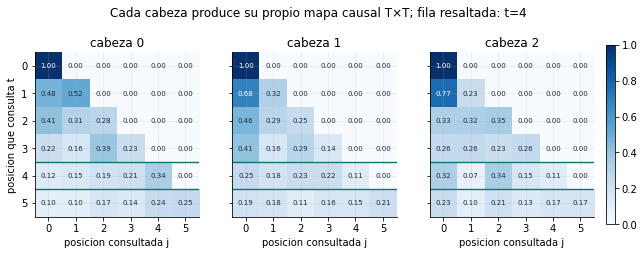

In [2]:
resultado_multihead = atencion_experimentos.preparar_multi_head_attention(
    batch_size=1,
    seq_len=6,
    n_embd=12,
    n_head=3,
    seed=7,
)

mostrar_tablas_en_columnas(
    [
        ("Auditoría eje por eje", resultado_multihead.auditoria),
        ("Traza para la posición t=4", resultado_multihead.traza_fila),
        ("Configuración", resultado_multihead.configuracion),
        ("Verificaciones", resultado_multihead.verificaciones),
    ],
    min_width="330px",
)


La auditoría muestra que multi-head attention no parte la secuencia: el eje $T$ se conserva en las operaciones principales. Lo que se reorganiza es el eje de canales: $C$ se lee como $H$ grupos de tamaño $D$.

La traza para $t=4$ permite mirar una fila concreta de atención en cada cabeza. Cada fila suma uno, no asigna masa al futuro y puede tener un máximo permitido diferente. Eso muestra diversidad de rutas de mezcla, pero no autoriza a nombrar cada cabeza como una función semántica humana.

## Visualización de mapas por cabeza

Cada cabeza genera una matriz de atención causal. Las filas son posiciones que consultan; las columnas son posiciones consultadas. Por la máscara causal, las celdas futuras deben quedar sin masa de probabilidad.

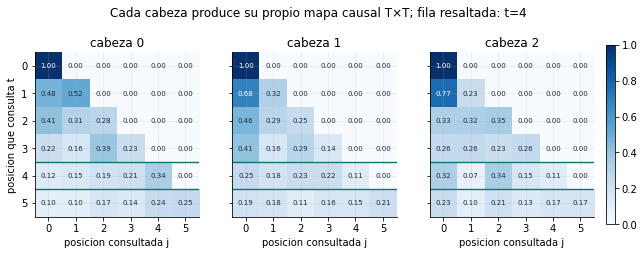

In [3]:
display(resultado_multihead.figura)
plt.close(resultado_multihead.figura)


Los mapas pueden diferir porque cada cabeza compara proyecciones distintas de la entrada. Sin embargo, en este experimento los pesos provienen de parámetros aleatorios; por tanto, las diferencias visuales solo muestran diversidad computacional, no especialización aprendida.

## Explorador interactivo

El siguiente componente permite variar $C$, $H$ y $T$, y también seleccionar una cabeza y una posición de consulta. Su función es hacer visible la restricción $C=H \cdot D$, la auditoría de formas y la lectura de una fila concreta $A[h,t,:]$ sin confundir cabezas con subconjuntos de tokens.

In [4]:
crear_explorador_multi_cabeza()

## Verificación de aprendizaje

Modifica el explorador y responde con evidencia concreta tomada de las tablas o de los mapas:

1. Elige una configuración válida, por ejemplo $C=16$ y $H=4$. Reporta $D$, la forma de $A$ y la forma de la salida final.
2. Elige una configuración inválida, por ejemplo $C=8$ y $H=3$. Explica por qué no puede formarse una atención multi-cabeza consistente.
3. Mantén $C$ fijo y aumenta $H$. ¿Qué ocurre con $D$? ¿Qué implica para la cantidad de canales disponibles por cabeza?
4. Selecciona una cabeza y una posición $t$. Reporta la suma de la fila $A[h,t,:]$, la masa futura y la posición permitida con mayor peso.
5. Compara dos cabezas para la misma posición $t$. Indica qué diferencia observable aparece en sus pesos y separa claramente qué puedes afirmar de la ruta de información y qué no puedes afirmar sobre significado semántico.
6. Verifica que cada cabeza conserva las mismas $T$ posiciones. ¿Qué eje cambia realmente cuando se pasa de $(B,T,C)$ a $(B,H,T,D)$?

## Análisis crítico

El experimento muestra tres hechos centrales. Primero, la atención multi-cabeza introduce un eje adicional $H$ para ejecutar varias atenciones en paralelo. Segundo, cada cabeza conserva todas las posiciones $T$, pero trabaja con $D$ canales. Tercero, concatenar cabezas recupera $C$ canales y la proyección $W_O$ mezcla esa información para preservar la interfaz de la red con una representación ya integrada.

La razón arquitectónica es que una sola comparación puede ser restrictiva: al dividir canales, el modelo puede aprender diferentes formas de proyectar y comparar posiciones. Si $C$ permanece fijo, aumentar $H$ no agrega canales totales; redistribuye la capacidad en más subespacios de menor dimensión.

Pero esta explicación debe mantenerse en el nivel correcto. En un modelo no entrenado, no hay base para atribuir significado lingüístico estable a una cabeza. Mapas distintos son evidencia de rutas de información distintas bajo una entrada y unos parámetros concretos; no son, por sí solos, una explicación semántica definitiva.

## Síntesis

La cadena operacional del notebook es:

$$
X \rightarrow QKV \rightarrow Q,K,V \rightarrow (B,H,T,D) \rightarrow A_h \rightarrow Y_h \rightarrow \operatorname{Concat} \rightarrow W_O \rightarrow Y.
$$

Esta cadena se lee así: una representación se proyecta por posición hacia $3C$ canales, se separa en consultas, claves y valores, sus canales se dividen en cabezas, cada cabeza calcula atención causal, las salidas se concatenan, la proyección final mezcla la información de las cabezas y el resultado vuelve a la forma $(B,T,C)$.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que la atención multi-cabeza multiplica las formas de comparar posiciones sin dividir tokens ni cambiar la interfaz externa de la capa.
</div>

## Preguntas de discusión

1. ¿Por qué una cabeza no debe interpretarse como un subconjunto de tokens?
2. ¿Qué condición matemática debe cumplirse para separar $C$ canales en $H$ cabezas?
3. ¿Qué cambia y qué permanece fijo cuando se aumenta $H$ manteniendo $C$ constante?
4. ¿Por qué mapas de atención visualmente distintos no prueban por sí solos especialización semántica?
5. ¿Por qué es importante que la salida final conserve forma $(B,T,C)$?

## Continuidad

La atención multi-cabeza produce una representación contextual, pero un bloque Transformer necesita más piezas para ser entrenable y estable: conexiones residuales, normalización y una red feed-forward por posición.

El notebook 11 estudia esas piezas y explica por qué el Transformer no es solo atención, sino una composición de atención, transformación por canales, estabilización y acumulación residual.